In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('.'))

from xso.parscans import run_xso_parscan

from cariaco_ssm_setup import model, model_setup, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets
from parscan_utils import (
    compute_cost_grid, find_best_fit, get_default_from_setup,
)
from parscan_plots import (
    plot_cost_heatmap, plot_model_vs_obs_bars,
    plot_model_vs_obs_boxplots, summarize_best_fit,
)

In [2]:
REGIME = 'all'   # 'all' | 'upwelling' | 'relaxed' | 'strong' | 'moderate' | 'weak'

obs_vec, labels, bin_defs, monthly_df = load_cariaco_targets(regime=REGIME)

print(f"Observation targets (regime='{REGIME}'):")
for lab, val in zip(labels, obs_vec):
    print(f"  {lab:20s}: {val:.5f}")
print(f"Months in filtered dataset: {len(monthly_df)}")

Observation targets (regime='all'):
  Pico (<2 µm)        : 0.09698
  Nano (2-20 µm)      : 0.08512
  Micro (>20 µm)      : 0.19977
  Zoo >200 µm         : 0.05938
  Zoo >500 µm         : 0.03302
  NO3                 : 1.46705
Months in filtered dataset: 255


In [3]:
# Which parameters to scan, their ranges, and grid resolution
P1_NAME   = 'Grazing__KsZ'
P1_LABEL  = 'Grazing K_half (mmol N m⁻³)'
P1_VALUES = np.linspace(0.1, 3.0, 10)

P2_NAME   = 'FishGrazing__rate'
P2_LABEL  = 'Fish predation rate (d⁻¹)'
P2_VALUES = np.linspace(0.001, 0.1, 10)

# Scan runtime settings
N_PROCESSES = 20
AVG_WINDOW  = 1000   # days at tail of IVP to average for steady-state cost

print(f"2D scan: {P1_NAME} ({len(P1_VALUES)} pts)  x  {P2_NAME} ({len(P2_VALUES)} pts)")
print(f"Total runs: {len(P1_VALUES) * len(P2_VALUES)}")

2D scan: Grazing__KsZ (10 pts)  x  FishGrazing__rate (10 pts)
Total runs: 100


In [4]:
scan_results = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup',
    param_name=P1_NAME,
    param_values=P1_VALUES,
    param_name2=P2_NAME,
    param_values2=P2_VALUES,
    processes=N_PROCESSES,
)

if scan_results is None:
    raise RuntimeError("Parameter scan failed — check output above.")

PROGRESS: Completed 10/10 outer points. (Grazing__KsZ = 3.0).

2D Scan complete. Total Time taken: 27.43219 seconds.


In [5]:
cost_grid, model_grid = compute_cost_grid(
    scan_results,
    phyto_esd=phyto_esd,
    zoo_esd=zoo_esd,
    obs_vec=obs_vec,
    bin_definitions=bin_defs,
    avg_window=AVG_WINDOW,
    dim1_name=P1_NAME,
    dim2_name=P2_NAME,
)

best = find_best_fit(cost_grid, model_grid, scan_results, P1_NAME, P2_NAME)

default = {
    'val1': get_default_from_setup(model_setup, P1_NAME),
    'val2': get_default_from_setup(model_setup, P2_NAME),
}

title_info = (f"{P1_NAME}={best['val1']:.4f}, "
              f"{P2_NAME}={best['val2']:.4f}, "
              f"cost={best['cost']:.3f}")

print(f"\n--- Best fit ---")
print(f"  {P1_LABEL}: {best['val1']:.5f}")
print(f"  {P2_LABEL}: {best['val2']:.5f}")
print(f"  Cost (NRMSRE): {best['cost']:.4f}")


--- Best fit ---
  Grazing K_half (mmol N m⁻³): 0.42222
  Fish predation rate (d⁻¹): 0.10000
  Cost (NRMSRE): 0.8297


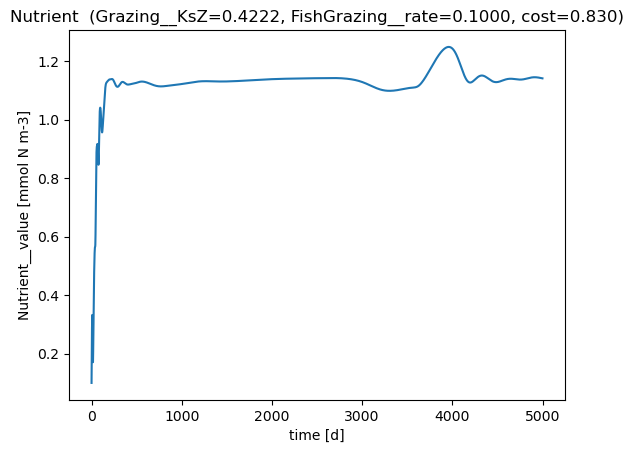

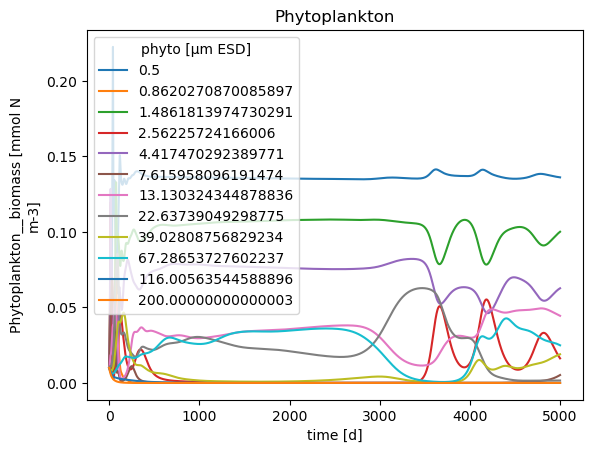

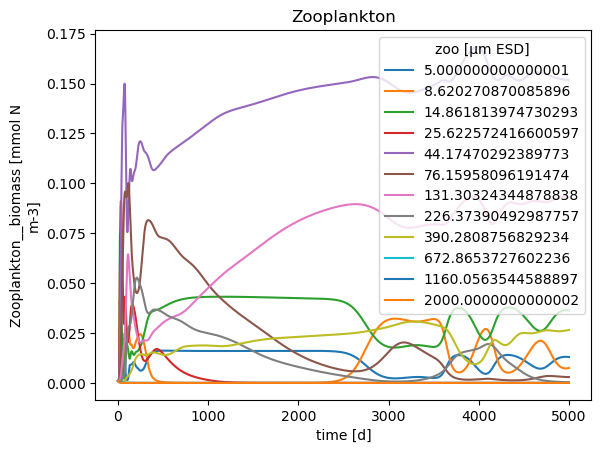

In [6]:
best_run = scan_results.sel({P1_NAME: best['val1'], P2_NAME: best['val2']},
                            method='nearest')

best_run['Nutrient__value'].plot.line(x='time')
plt.title(f'Nutrient  ({title_info})')
plt.show()

best_run['Phytoplankton__biomass'].plot.line(x='time')
plt.title('Phytoplankton')
plt.show()

best_run['Zooplankton__biomass'].plot.line(x='time')
plt.title('Zooplankton')
plt.show()

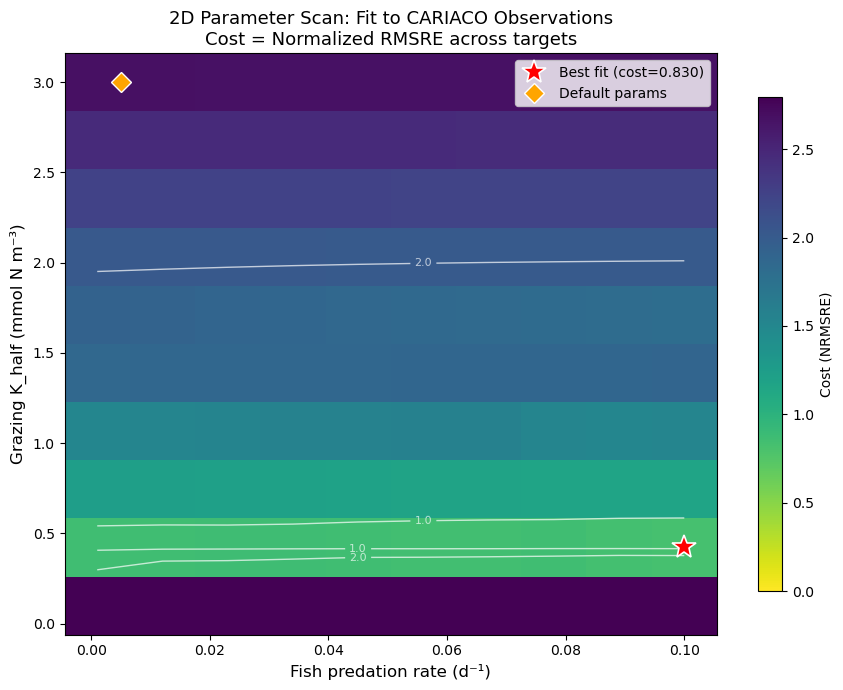

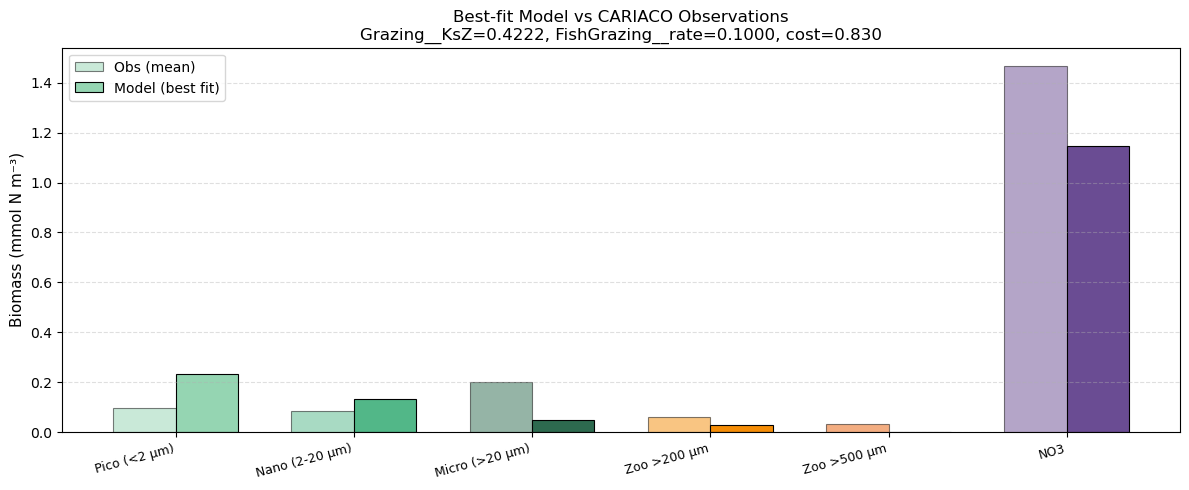

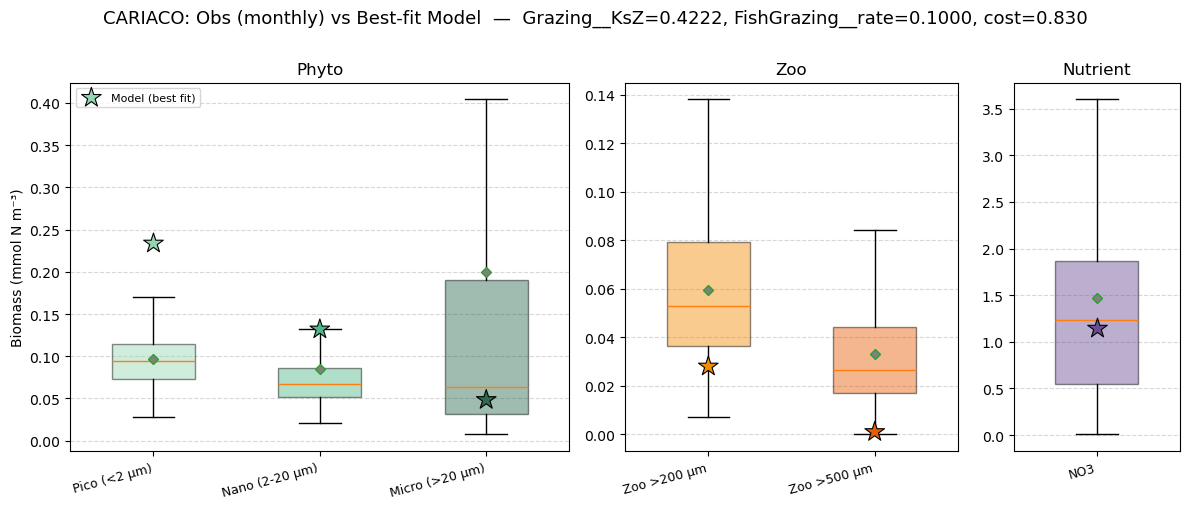

In [7]:
fig1 = plot_cost_heatmap(cost_grid, P1_VALUES, P2_VALUES,
                         P1_LABEL, P2_LABEL, best, default=default)
plt.show()

fig2 = plot_model_vs_obs_bars(best['model_vec'], obs_vec, bin_defs,
                              title_info=title_info)
plt.show()

fig3 = plot_model_vs_obs_boxplots(best['model_vec'], monthly_df, bin_defs,
                                  title_info=title_info)
plt.show()

In [8]:
summary = summarize_best_fit(
    model_vec=best['model_vec'],
    obs_vec=obs_vec,
    labels=labels,
    cost=best['cost'],
)


 BEST-FIT SUMMARY  |  Overall cost (NRMSRE): 0.8297
     Component  Obs_Mean  Model_BestFit   Ratio  Rel_Error_%
  Pico (<2 µm)   0.09698        0.23370 2.40979    140.97910
Nano (2-20 µm)   0.08512        0.13196 1.55035     55.03484
Micro (>20 µm)   0.19977        0.04836 0.24208    -75.79228
   Zoo >200 µm   0.05938        0.02805 0.47234    -52.76561
   Zoo >500 µm   0.03302        0.00102 0.03093    -96.90710
           NO3   1.46705        1.14678 0.78169    -21.83077
